In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [22]:
from pathlib import Path

# -----------------------
# File paths
# -----------------------

base_dir = Path(
    "RFID-ExSim-dataset/rfid_dataset/rfid_dataset/data/processed"
)

paths = {
    "S1": base_dir / "rfid_dataset_S1_all.jsonl",
    "S2": base_dir / "rfid_dataset_S2_all.jsonl",
    "S3": base_dir / "rfid_dataset_S3_all.jsonl",
    "S4": base_dir / "rfid_dataset_S4_all.jsonl",
    "S5": base_dir / "rfid_dataset_S5_all.jsonl",
}

# Confirm files exist
for scenario, path in paths.items():
    print(scenario, path, "exists:", path.exists())

# -----------------------
# Load and merge datasets
# -----------------------

dfs = []

for scenario, path in paths.items():
    temp = pd.read_json(path, lines=True)

    # Keep scenario from filename as reliable label
    temp["scenario"] = scenario

    # S1 = normal, S2-S5 = anomaly
    temp["label"] = 0 if scenario == "S1" else 1

    dfs.append(temp)

df_all = pd.concat(dfs, ignore_index=True)

print("Full dataset shape:", df_all.shape)
print(df_all["scenario"].value_counts())
print(df_all.columns)

df_all.head()

S1 RFID-ExSim-dataset/rfid_dataset/rfid_dataset/data/processed/rfid_dataset_S1_all.jsonl exists: True
S2 RFID-ExSim-dataset/rfid_dataset/rfid_dataset/data/processed/rfid_dataset_S2_all.jsonl exists: True
S3 RFID-ExSim-dataset/rfid_dataset/rfid_dataset/data/processed/rfid_dataset_S3_all.jsonl exists: True
S4 RFID-ExSim-dataset/rfid_dataset/rfid_dataset/data/processed/rfid_dataset_S4_all.jsonl exists: True
S5 RFID-ExSim-dataset/rfid_dataset/rfid_dataset/data/processed/rfid_dataset_S5_all.jsonl exists: True
Full dataset shape: (408422, 15)
scenario
S5    289523
S4     41719
S3     32400
S2     31776
S1     13004
Name: count, dtype: int64
Index(['timestamp_iso', 'session_id', 'scenario', 'device_id', 'port',
       'tag_local_id', 'uid_hash', 'uid_plain_local', 'distance_cm',
       'orientation_deg', 'event', 'raw_payload', 'label', 'reader',
       'source_file'],
      dtype='object')


,timestamp_iso,session_id,scenario,device_id,port,tag_local_id,uid_hash,uid_plain_local,distance_cm,orientation_deg,event,raw_payload,label,reader,source_file
0,2025-11-04 08:12:55.469573+00:00,S20251104_S1_TAG01_d1_o0_run1,S1,ESP32_B,COM4,TAG01,9720a7f2733d,83C11D13,1.0,0.0,read_success,UID: 83 C1 1D 13,0,NaN,NaN
1,2025-11-04 08:13:09.703865+00:00,S20251104_S1_TAG01_d1_o0_run1,S1,ESP32_B,COM4,TAG01,9720a7f2733d,83C11D13,1.0,0.0,read_success,UID: 83 C1 1D 13,0,NaN,NaN
2,2025-11-04 08:13:15.142252+00:00,S20251104_S1_TAG01_d1_o0_run1,S1,ESP32_B,COM4,TAG01,9720a7f2733d,83C11D13,1.0,0.0,read_success,UID: 83 C1 1D 13,0,NaN,NaN
3,2025-11-04 08:13:16.930616+00:00,S20251104_S1_TAG01_d1_o0_run1,S1,ESP32_B,COM4,TAG01,9720a7f2733d,83C11D13,1.0,0.0,read_success,UID: 83 C1 1D 13,0,NaN,NaN
4,2025-11-04 08:13:20.141495+00:00,S20251104_S1_TAG01_d1_o0_run1,S1,ESP32_B,COM4,TAG01,9720a7f2733d,83C11D13,1.0,0.0,read_success,UID: 83 C1 1D 13,0,NaN,NaN


In [23]:
# -----------------------
# Feature engineering
# -----------------------

df_all["timestamp"] = pd.to_datetime(df_all["timestamp_iso"])

# Sort within each scenario/session before computing time gaps
df_all = df_all.sort_values(
    ["scenario", "session_id", "timestamp"]
).reset_index(drop=True)

# Time between reads within the same scenario + session
df_all["delta_t"] = (
    df_all.groupby(["scenario", "session_id"])["timestamp"]
    .diff()
    .dt.total_seconds()
    .fillna(0)
)
print(df_all.head)
# Encode categorical variables
df_all["device_id_enc"] = df_all["device_id"].astype("category").cat.codes
df_all["tag_id_enc"] = df_all["tag_local_id"].astype("category").cat.codes

# Baseline feature list
features = [
    "delta_t",
    "distance_cm",
    "orientation_deg"#, #remove device id info
    #"device_id_enc",
    #"tag_id_enc"
]

# Remove rows with missing features
df_all = df_all.dropna(subset=features).reset_index(drop=True)

print("After feature engineering:", df_all.shape)
print(df_all[features].head())

<bound method NDFrame.head of                           timestamp_iso                     session_id  \
0      2025-11-04 08:12:55.469573+00:00  S20251104_S1_TAG01_d1_o0_run1   
1      2025-11-04 08:13:09.703865+00:00  S20251104_S1_TAG01_d1_o0_run1   
2      2025-11-04 08:13:15.142252+00:00  S20251104_S1_TAG01_d1_o0_run1   
3      2025-11-04 08:13:16.930616+00:00  S20251104_S1_TAG01_d1_o0_run1   
4      2025-11-04 08:13:20.141495+00:00  S20251104_S1_TAG01_d1_o0_run1   
...                                 ...                            ...   
408417 2025-11-11 12:09:38.061261+00:00                  S5_TAG12_run3   
408418 2025-11-11 12:09:38.061677+00:00                  S5_TAG12_run3   
408419 2025-11-11 12:09:38.062372+00:00                  S5_TAG12_run3   
408420 2025-11-11 12:09:38.063483+00:00                  S5_TAG12_run3   
408421 2025-11-11 12:09:38.064595+00:00                  S5_TAG12_run3   

       scenario device_id  port tag_local_id      uid_hash uid_plain_local  \
0  

In [24]:
# -----------------------
# Train on S1 only
# -----------------------

train_df = df_all[df_all["scenario"] == "S1"].copy()

X_train = train_df[features]

# Scale using only normal training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Train Isolation Forest
model = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=42
)

model.fit(X_train_scaled)

print("Training complete.")
print("Training rows:", X_train.shape[0])

Training complete.
Training rows: 12472


In [25]:
# -----------------------
# Test on merged S1-S5
# -----------------------

test_df = df_all.copy()

X_test = test_df[features]
y_test = test_df["label"]

# Use the same scaler fitted on S1
X_test_scaled = scaler.transform(X_test)

# Predict
raw_preds = model.predict(X_test_scaled)

# Isolation Forest output:
#  1 = normal
# -1 = anomaly
#
# Convert to:
# 0 = normal
# 1 = anomaly
test_df["pred"] = np.where(raw_preds == -1, 1, 0)

# Higher score = more anomalous
test_df["anomaly_score"] = -model.decision_function(X_test_scaled)

# -----------------------
# Overall evaluation
# -----------------------

print("Confusion Matrix:")
print(confusion_matrix(y_test, test_df["pred"]))

print("\nClassification Report:")
print(classification_report(y_test, test_df["pred"]))

# -----------------------
# Scenario-level results
# -----------------------

scenario_summary = test_df.groupby("scenario").agg(
    total=("pred", "count"),
    true_anomaly_rate=("label", "mean"),
    predicted_anomalies=("pred", "sum"),
    predicted_anomaly_rate=("pred", "mean"),
    avg_anomaly_score=("anomaly_score", "mean")
)

scenario_summary

Confusion Matrix:
[[ 9256  3216]
 [21636 84259]]

Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.74      0.43     12472
           1       0.96      0.80      0.87    105895

    accuracy                           0.79    118367
   macro avg       0.63      0.77      0.65    118367
weighted avg       0.89      0.79      0.82    118367



,total,true_anomaly_rate,predicted_anomalies,predicted_anomaly_rate,avg_anomaly_score
scenario,,,,,
S1,12472,0.0,3216,0.257858,-0.009880
S2,31776,1.0,25641,0.806930,0.013923
S3,32400,1.0,21600,0.666667,0.021128
S4,41719,1.0,37018,0.887318,0.022894


# use sliding windows to incorporate time series information


In [26]:

def make_sliding_windows(
    df,
    session_cols=["scenario", "session_id"],
    time_col="timestamp",
    window_size="30s",
    step_size="10s"
):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    rows = []

    window_size = pd.Timedelta(window_size)
    step_size = pd.Timedelta(step_size)

    for session_key, g in df.groupby(session_cols):
        g = g.sort_values(time_col)

        start = g[time_col].min()
        end = g[time_col].max()

        t = start
        while t + window_size <= end:
            w = g[(g[time_col] >= t) & (g[time_col] < t + window_size)]

            if len(w) > 0:
                row = {
                    "window_start": t,
                    "window_end": t + window_size,
                    "n_reads": len(w),

                    "delta_t_mean": w["delta_t"].mean(),
                    "delta_t_std": w["delta_t"].std(),
                    "delta_t_max": w["delta_t"].max(),

                    "distance_mean": w["distance_cm"].mean(),
                    "distance_std": w["distance_cm"].std(),
                    "distance_min": w["distance_cm"].min(),
                    "distance_max": w["distance_cm"].max(),

                    "orientation_mean": w["orientation_deg"].mean(),
                    "orientation_std": w["orientation_deg"].std(),
                    "orientation_min": w["orientation_deg"].min(),
                    "orientation_max": w["orientation_deg"].max(),
                }

                if isinstance(session_key, tuple):
                    for col, val in zip(session_cols, session_key):
                        row[col] = val
                else:
                    row[session_cols[0]] = session_key

                rows.append(row)

            t += step_size

    return pd.DataFrame(rows)

In [35]:
df_all = pd.concat(dfs, ignore_index=True)
df_all["timestamp_iso"] = pd.to_datetime(df_all["timestamp_iso"])

df_all = df_all.sort_values(
    ["scenario", "session_id", "timestamp_iso"]
)

df_all["delta_t"] = (
    df_all
    .groupby(["scenario", "session_id"])["timestamp_iso"]
    .diff()
    .dt.total_seconds()
)

df_all["delta_t"] = df_all["delta_t"].fillna(0)
# Build window-level dataset
window_df = make_sliding_windows(
    df_all,
    session_cols=["scenario", "session_id"],
    time_col="timestamp_iso",
    window_size="30s",
    step_size="10s"
)

window_df = window_df.fillna(0)

features = [
    "n_reads",
    "delta_t_mean", "delta_t_std", "delta_t_max",
    "distance_mean", "distance_std", "distance_min", "distance_max",
    "orientation_mean", "orientation_std", "orientation_min", "orientation_max"
]

# Normal data only
s1_df = window_df[window_df["scenario"] == "S1"].copy()

# Split S1 into train/test
s1_train, s1_test = train_test_split(
    s1_df,
    test_size=0.25,
    random_state=42,
    shuffle=True
)

# Test set = held-out S1 + all anomalies/other scenarios
other_test = window_df[window_df["scenario"] != "S1"].copy()

test_df = pd.concat([s1_test, other_test], ignore_index=True)

# Scale using training data only
scaler = StandardScaler()

X_train = scaler.fit_transform(s1_train[features])
X_test = scaler.transform(test_df[features])

# Train on only 75% of S1
model = IsolationForest(
    n_estimators=200,
    contamination=0.11,
    random_state=42
)

model.fit(X_train)

# Predict on held-out S1 + S2-S5
raw_preds = model.predict(X_test)

test_df["pred_anomaly"] = (raw_preds == -1).astype(int)
test_df["anomaly_score"] = -model.decision_function(X_test)

# Optional ground-truth label
test_df["true_anomaly"] = (test_df["scenario"] != "S1").astype(int)

[[495  75]
 [ 24  84]]
              precision    recall  f1-score   support

           0       0.95      0.87      0.91       570
           1       0.53      0.78      0.63       108

    accuracy                           0.85       678
   macro avg       0.74      0.82      0.77       678
weighted avg       0.89      0.85      0.86       678



<Axes: xlabel='anomaly_score', ylabel='Count'>

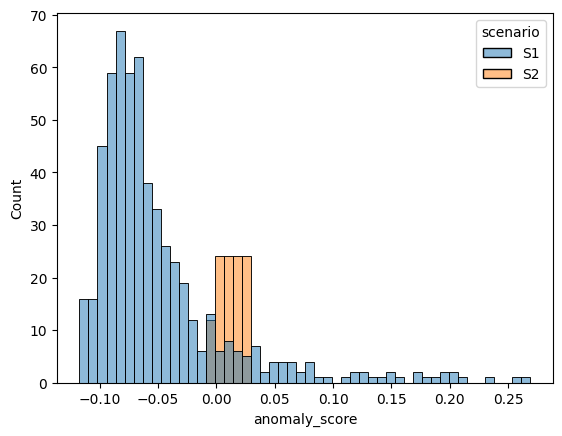

In [38]:
print(confusion_matrix(test_df["true_anomaly"], test_df["pred_anomaly"]))
print(classification_report(test_df["true_anomaly"], test_df["pred_anomaly"]))
sns.histplot(data=test_df, x="anomaly_score", hue="scenario", bins=50)

Contam results
.5 bad .15 bad

.10

[[503  67]

 [ 36  72]]
              precision    recall  f1-score   support

           0       0.93      0.88      0.91       570
           1       0.52      0.67      0.58       108

    accuracy                           0.85       678
   macro avg       0.73      0.77      0.75       678
weighted avg       0.87      0.85      0.86       678


.11

[[495  75]

 [ 24  84]]
              precision    recall  f1-score   support

           0       0.95      0.87      0.91       570
           1       0.53      0.78      0.63       108

    accuracy                           0.85       678
   macro avg       0.74      0.82      0.77       678
weighted avg       0.89      0.85      0.86       678